# More Reliable Automatic Deep Research System  

## Introduction  

This notebook demonstrates a multi-agent research workflow designed to produce more reliable and structured research outputs using AI agents.

The system leverages a coordinated group of agents powered by CrewAI, external search tools, and structured task orchestration. Each agent performs a specialized role in the research pipeline, including planning, information gathering, fact checking, and report generation.

The goal is to improve the reliability of automated research by introducing:

• Structured task decomposition  
• Multiple specialized agents  
• Verification and guardrails  
• External search and website scraping tools
• Execution hooks to inject logic after the agents run  
• Add memory to your crew   


Here it  will be used what it has been already built in [Automatic_Deep_Research](https://github.com/micag2025/Build_Deploy_Muti_Agents_Crewai/tree/main/Automatic_Deep_Research), and `add decision making tools`, like `execution hooks and guardrails`, as well as `memory` to improve the reliability of the crew.



## 📌 Overview

This system implements a **multi-agent research pipeline** designed to produce reliable, verifiable, and structured research outputs.

Unlike simple search-based approaches, this system:
- Plans research strategically
- Gathers diverse sources
- Validates information
- Produces high-quality reports  

## 🎯 Objectives

- Improve research reliability
- Reduce misinformation
- Ensure traceable and verifiable outputs
- Automate structured report generation


## 📚 Background

### Problem

In modern information environments, conducting reliable research is increasingly challenging due to the overwhelming volume of available data and the presence of inconsistent, outdated, or biased sources. Traditional approaches—such as simple search-and-summarize pipelines—often fail to ensure accuracy, completeness, and traceability. 

A key issue is that research involves multiple distinct cognitive steps: planning what to അന്വേഷ, gathering diverse information, validating sources, and synthesizing findings. When these steps are handled by a single system or agent, the result is often shallow analysis, lack of verification, and increased risk of misinformation. This creates a need for a more structured and reliable approach to automated research.

---

### Solution

To address this challenge, the system adopts a **multi-agent architecture** in which each stage of the research process is handled by a specialized agent. The workflow is divided into four key stages:

1. **Research Planning** – defining topics, questions, and success criteria  
2. **Information Gathering** – collecting data from multiple sources  
3. **Validation & Fact Checking** – ensuring accuracy and identifying inconsistencies  
4. **Report Generation** – synthesizing verified information into a structured output  

By decomposing the research process into these distinct roles, the system ensures that each step is performed with greater focus and rigor. This approach improves the reliability, transparency, and overall quality of the final output, transforming the pipeline from a simple retrieval system into a **trust-aware research workflow**.

---

###  Why CrewAI

CrewAI is particularly well-suited for implementing this solution because it enables the design of **role-based, collaborative agents** with clearly defined goals, responsibilities, and tools. It provides a structured framework for orchestrating tasks in a sequential and modular way, allowing each agent to operate independently while contributing to a cohesive workflow.

Additionally, CrewAI supports:
- **Task orchestration**, enabling clear execution pipelines  
- **Tool integration**, allowing agents to access external data sources  
- **Separation of concerns**, improving maintainability and scalability  

This makes CrewAI an ideal foundation for building a **scalable, extensible, and reliable multi-agent research system**, closely mirroring how human research teams operate in practice.


## Architecture Overview  

The system follows a **sequential multi-agent workflow**:

1. Research Planning  
2. Data Collection  
3. Validation & Fact Checking  
4. Report Generation  

---

## 👥 Agents

### 👤 Research Planner
**Role:** Strategic Orchestrator  
**Goal:** Design a structured research plan  
**Responsibility:**
- Break down query into topics
- Define research questions
- Set success criteria  

---

### 🔍 Internet Researcher
**Role:** Data Gatherer  
**Goal:** Collect high-quality, relevant information  
**Tools:**
- EXA Search Tool  
- Web Scraper Tool  

---

### ✅ Fact Checker
**Role:** Quality Assurance  
**Goal:** Validate accuracy and detect inconsistencies  

---

### 📝 Report Writer
**Role:** Communication Expert  
**Goal:** Produce a structured, publication-ready report  

---


### CrewAI Workflow — Deep Research System

```bash  
User Query
   ↓
[👤 Research Planner Agent]  
   Role: Strategic Orchestrator  
   Goal: Create a structured research roadmap  
   Tools: None  

   ↓
   [Research Planning Task]
   ← Break down query into topics  
   ← Define research questions  
   ← Set success criteria  
   ↓

[🔍 Internet Researcher Agent]  
   Role: Data Gatherer  
   Goal: Collect relevant and credible information  

   Tools:
   - EXA Search Tool  
   - Web Scraper Tool  

   ↓
   [Research Execution Task]
   ← Search for relevant sources  
   ← Extract key insights  
   ← Provide citations with credibility notes  
   ↓

[✅ Fact Checker Agent]  
   Role: Quality Assurance Officer  
   Goal: Validate accuracy and completeness  
   Tools: None  

   ↓
   [Validation Task]
   ← Cross-reference multiple sources  
   ← Identify conflicts and bias  
   ← Highlight missing information  
   ↓

[📝 Report Writer Agent]  
   Role: Communication Expert  
   Goal: Produce a structured research report  
   Tools: Formatting frameworks  

   ↓
   [Report Writing Task]
   ← Organize findings logically  
   ← Write executive summary  
   ← Format with proper citations  
   ↓

📘 Final Output
   - Verified Research Report  
   - Source Citations  
   - Reliability Assessment  
```

The research process follows this sequence:

1. **Research Planner** – creates a structured research plan
2. **Internet Researcher** – gathers supporting information
3. **Fact Checker** – validates sources and claims
4. **Report Writer** – synthesizes the findings into a final report

This modular architecture allows the system to produce higher-quality outputs compared to a single LLM prompt. In order to make the output more reliable,  `new  guardrails, execution hooks and memory` will be added into strategic elements of Crew`.  

The below diagram diplays the structure of this crew. 


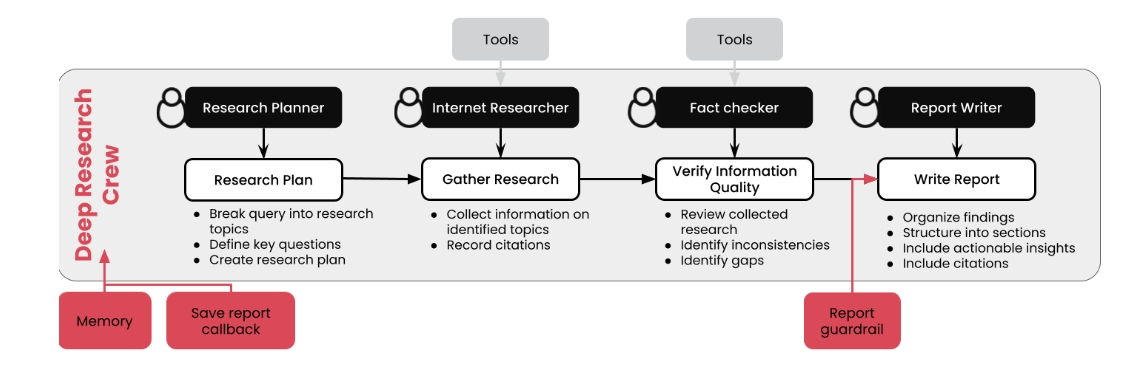

In [1]:
from IPython.display import Image, display
display(Image('More_Reliable_Automatic_Deep_Research/diagram_flow2.jpeg'))

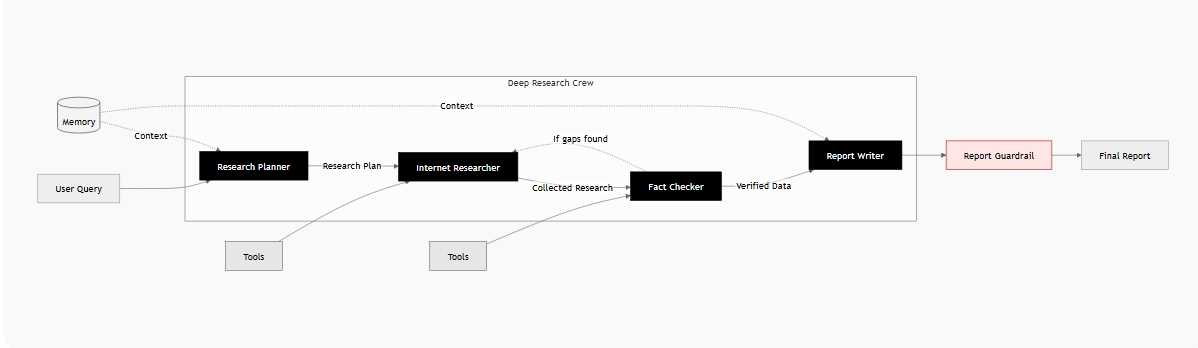

In [2]:
from IPython.display import Image, display
display(Image('More_Reliable_Automatic_Deep_Research/new_diagram_flow2.jpeg'))

## Installation & Setup 

Firstlly install required libraries , then import the necessary modules and configure API Keys

In [ ]:
#_Note_ Install the dependencies from the notebook and not from the requirement file.
#pip install -r requirements.txt

In [ ]:
# Install required dependencies

%pip install ptyprocess
%pip install ipykernel
%pip install pyzmq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.1 MB/s eta 0:00:00


In [4]:
%pip install onnxruntime==1.20.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.1 MB/s eta 0:00:00


In [5]:
%pip install exa-py
%pip install crewai
%pip install crewai-tools
%pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 5.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opentelemetry-exporter-otlp-proto-grpc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 886.2/886.2 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [ ]:
# Install required dependencies
#%pip install -q \
#    ptyprocess \
#    ipykernel \
#    pyzmq \
#    onnxruntime==1.20.0 \
#    exa-py \
#    crewai \
#    crewai-tools \
#    langchain-openai

In [ ]:
# Import modules
import os
import re
import yaml
import warnings
from google.colab import userdata

# AI framework imports
from crewai import Agent, Task, Crew
from crewai_tools import EXASearchTool, ScrapeWebsiteTool
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

warnings.filterwarnings("ignore")

# Disable CrewAI internal retrieval to rely solely on external search tools
os.environ["CREWAI_DISABLE_RAG"] = "true"

# -------------------------------------------------------
# API Keys
# -------------------------------------------------------

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["EXA_API_KEY"] = userdata.get("EXA_API_KEY")

# -------------------------------------------------------
# Models
# -------------------------------------------------------

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

## Define the agents

For this system, you will use four agents:    
- **Research Planner**    
- **Internet Researcher**  
- **Fact checker**  
- **Report Writer**    

All their arguments (`role`, `goal`, `backstory`) are given in the YAML format. The configurations of the agents can been dowloaded from [config/agents.yaml](config/agents.yaml) 

Run the next cell to create an instance of each agent, as well as the tools for the **Internet Researcher** agents.

In [ ]:
# -------------------------------------------------------
# Tool Definitions
# -------------------------------------------------------
# These tools allow agents to access external information
# sources during the research process.

# Web search tool powered by EXA
exa_search_tool = EXASearchTool(
    api_key=os.getenv("EXA_API_KEY"),
    base_url="https://api.exa.ai"
)

# Tool for extracting structured content from webpages
scrape_website_tool = ScrapeWebsiteTool()

# -------------------------------------------------------
# Load Agent Config
# -------------------------------------------------------

with open("config/agents.yaml", "r") as file:
    agent_config = yaml.safe_load(file)

# -------------------------------------------------------
# Agents
# -------------------------------------------------------

research_planner = Agent(
    config=agent_config["research_planner"],
    llm=llm,
    verbose=True
)

internet_researcher = Agent(
    config=agent_config["internet_researcher"],
    llm=llm,
    tools=[exa_search_tool, scrape_website_tool],
    verbose=True
)

fact_checker = Agent(
    config=agent_config["fact_checker"],
    llm=llm,
    tools=[exa_search_tool, scrape_website_tool],
    verbose=True
)

report_writer = Agent(
    config=agent_config["report_writer"],
    llm=llm,
    verbose=True
)

## Guardrails

To make the system more robust, it has been added `guardrails to the tasks`. These guardrails provide a way to validate and transform task outputs before they are passed to the next task, helping ensure data quality and providing feedback to agents when their output doesn't meet specific criteria. You can find out more about guardrails in the [docs](https://docs.crewai.com/en/concepts/tasks#task-guardrails).

Here, you will be working with [**Task Guardrails**](https://docs.crewai.com/en/concepts/tasks#task-guardrails). These are custom functions that check if a task's output meets your requirements before passing it to the next task. They help ensure quality and give feedback to agents when their work needs improvement.

The guardrail functions must accept exactly one parameter (the task output they are reviewing), and should return a tuple of `(bool, Any)`. If the validation is successful, it returns a tuple of `(bool, Any)`. For example: (True, validated_result). If it fails, it needs to return a tuple of `(bool, str)`. For example: (False, "Error message explaining the failure"). For more information, you can check out the [docs](https://docs.crewai.com/en/concepts/tasks#task-guardrails).

In particular, the `final output` wiil be implemented with a guardrail in order that the final report has all the sections needed:
- **Summary**  
- **Insights (or recommendations)**  
- **Citations (or References)**  

In [8]:
# -------------------------------------------------------
# Guardrail
# -------------------------------------------------------

def write_report_guardrail(output):
    """Ensure report structure is valid"""

    try:
        output = output if isinstance(output, str) else output.raw
    except Exception as e:
        return (False, f"Output extraction error: {str(e)}")

    output_lower = output.lower()

    if not re.search(r"#+.*summary", output_lower):
        return (False, "Report must include a Summary section.")

    if not re.search(r"(#+.*insights|#+.*recommendations)", output_lower):
        return (False, "Report must include Insights or Recommendations.")

    if not re.search(r"(#+.*citations|#+.*references)", output_lower):
        return (False, "Report must include a Citations or References section.")

    return (True, output)


## Tasks  
    
The configurations of the tasks can been dowloaded from [`config/tasks.yaml`](config/tasks.yaml).

In [ ]:
# -------------------------------------------------------
# Load Task Config
# -------------------------------------------------------

with open("config/tasks.yaml", "r") as file:
    task_config = yaml.safe_load(file)

# -------------------------------------------------------
# Tasks
# -------------------------------------------------------

create_research_plan = Task(
    config=task_config["create_research_plan"],
    agent=research_planner
)

gather_research_data = Task(
    config=task_config["gather_research_data"],
    agent=internet_researcher
)

verify_information_quality = Task(
    config=task_config["verify_information_quality"],
    agent=fact_checker
)

write_final_report = Task(
    config=task_config["write_final_report"],
    agent=report_writer,
    guardrails=[write_report_guardrail]
)

## Execution hooks  

The last step before creating the Crew is creating an [after kickoff hook](https://docs.crewai.com/en/learn/before-and-after-kickoff-hooks#after-kickoff-hook). This is a function that will execute after your crew has finished all the tasks. These functions receive a result object, which contains the outputs of the crew's execution.

In this case, it has been created a `hook` that takes the final output and saves it to a Markdown file on your local file system.

In [10]:
# -------------------------------------------------------
# Execution Hook
# -------------------------------------------------------

def save_file_hook(result):
    """Save final report"""

    try:
        if hasattr(result, "tasks_output") and result.tasks_output:
            report_content = result.tasks_output[-1].raw
        else:
            report_content = str(result)

        os.makedirs("outputs", exist_ok=True)

        filepath = "outputs/research_report.md"

        with open(filepath, "w", encoding="utf-8") as f:
            f.write(report_content)

        print(f"\nReport saved to: {filepath}")

    except Exception as e:
        print(f"Error saving report: {str(e)}")

## Assemble and Execute the Crew

In [ ]:
# -------------------------------------------------------
# Crew
# -------------------------------------------------------

deep_research_crew = Crew(

    agents=[
        research_planner,
        internet_researcher,
        fact_checker,
        report_writer
    ],

    tasks=[
        create_research_plan,
        gather_research_data,
        verify_information_quality,
        write_final_report
    ],

    memory=True,

    llm=llm,
    embeddings=embeddings,

    after_kickoff_callbacks=[save_file_hook]
)


### Define the inputs

Use the next cell to define the inputs to your Crew. This should represent the user's query. Write your own query, what would you like information about?

In [13]:
# -------------------------------------------------------
# Inputs
# -------------------------------------------------------

inputs = {
    "user_query": "List top 2 AI platforms for developers."
}

# -------------------------------------------------------
# Run Crew
# -------------------------------------------------------

result = deep_research_crew.kickoff(inputs=inputs)

print("\nFinal Result:\n")
print(result)


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Research Planner                                                                                        │
│                                                                                                                 │
│  Task: Break down "List top 2 AI platforms for developers." into focused research topics, key questions, and    │
│  success criteria.                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Research Planner                                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Structured Research Plan: Listing Top 2 AI Platforms for Developers                                        │
│                                                                                                                 │
│  #### 1. Main Topics                                                                                            │
│  - **Market Overview of AI Platforms**                                                                          │
│  - **Key Features of AI Platforms**                                                                             │
│  - **Developer Community and Support**                                                                          │
│  - **Integration and Compatibility**                                                                            │
│  - **Cost and Pricing Models**                                                                                  │
│  - **Use Cases and Applications**                                                                               │
│                                                                                                                 │
│  #### 2. Key Questions per Topic                                                                                │
│                                                                                                                 │
│  **Market Overview of AI Platforms**                                                                            │
│  - What are the leading AI platforms currently available for developers?                                        │
│  - How do these platforms rank in terms of market share and popularity?                                         │
│  - What are the emerging trends in AI platforms for developers?                                                 │
│                                                                                                                 │
│  **Key Features of AI Platforms**                                                                               │
│  - What are the core functionalities offered by the top AI platforms?                                           │
│  - How do these features cater to the needs of developers?                                                      │
│  - What differentiates these platforms from one another in terms of technology and usability?                   │
│                                                                                                                 │
│  **Developer Community and Support**                                                                            │
│  - What is the size and activity level of the developer community for each platform?                            │
│  - What resources (documentation, forums, tutorials) are available for developers?                              │
│  - How responsive is the support provided by the platform vendors?                                              │
│                                                                                                                 │
│  **Integration and Compatibility**                                                                              │
│  - What programming languages and frameworks are supported by the top AI platforms?                             │
│  - How easily can these platforms be integrated with ex

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Internet Researcher                                                                                     │
│                                                                                                                 │
│  Task: Using the research plan, collect and verify comprehensive information from multiple credible sources.    │
│  Cite all sources.                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Tool exa_search_tool executed with result: Title: Microsoft's Azure AI Studio lets developers build their own AI 'copilots' | TechCrunch
URL: https://techcrunch.com/2023/05/23/microsoft-debuts-azure-ai-studio-to-let-developers-build-their-own-...
Tool exa_search_tool executed with result: Title: A Developer's Guide to Building Scalable AI: Workflows vs Agents
URL: https://towardsdatascience.com/a-developers-guide-to-building-scalable-ai-workflows-vs-agents/
ID: https://towardsdatascien...
Tool exa_search_tool executed with result: Title: Developers Use AI Coding Tools To Get Started, Not Finish The Job
URL: https://www.forbes.com/sites/joetoscano1/2026/01/20/developers-use-ai-coding-tools-to-get-started-not-finish-the-job/
ID: ...
Tool exa_search_tool executed with result: Title: Best Data Integration Tools Reviews 2026 | Gartner Peer Insights
URL: https://www.gartner.com/reviews/market/data-integration-tools
ID: https://www.gartner.com/reviews/market/data-integration-t...
Tool exa_sea

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Internet Researcher                                                                                     │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Research Dataset: Top AI Platforms for Developers                                                          │
│                                                                                                                 │
│  #### 1. Market Overview of AI Platforms                                                                        │
│  - **Leading AI Platforms**: The two leading AI platforms for developers are **Microsoft Azure AI** and         │
│  **Google Cloud AI**.                                                                                           │
│    - **Microsoft Azure AI**: Offers tools like Azure AI Studio, which allows developers to build custom AI      │
│  applications using OpenAI models. It serves over 4,500 companies, including major brands like Volvo and IKEA   │
│  (TechCrunch, 2023).                                                                                            │
│    - **Google Cloud AI**: Provides access to foundation models through APIs and tools like Vertex AI, which     │
│  supports generative AI applications and integrates with various data sources (TechCrunch, 2023).               │
│                                                                                                                 │
│  - **Market Share and Popularity**: According to Gartner, over 80% of enterprises will have deployed            │
│  generative AI-enabled applications by 2026, indicating a significant shift towards AI integration in business  │
│  processes (Gartner, 2023).                                                                                     │
│                                                                                                                 │
│  - **Emerging Trends**: The trend towards low-code and no-code platforms is growing, allowing developers to     │
│  create AI applications without extensive programming knowledge (ZDNet, 2023).                                  │
│                                                                                                                 │
│  #### 2. Key Features of AI Platforms                                                                           │
│  - **Core Functionalities**:                                                                                    │
│    - **Microsoft Azure AI**: Features include the ability to build AI copilots, integrate with proprietary      │
│  data, and utilize advanced models like GPT-4 (TechCrunch, 2023).                                               │
│    - **Google Cloud AI**: Offers tools for building and deploying machine learning models, including support    │
│  for generative AI and APIs for easy integration (TechCrunch, 2023).                                            │
│                                                                                                                 │
│  - **Differentiation**: Azure AI focuses on enterprise solutions with strong governance features, while Google  │
│  Cloud emphasizes an open ecosystem approach, allowing for flexibility and integration with third-party models  │
│  (TechCrunch, 2023).                                                                                            │
│                                                                                                                 │
│  #### 3. Developer Community and Support               

...


Report saved to: outputs/research_report.md


╭─────────────────────────────────────────────── Execution Traces ────────────────────────────────────────────────╮
│                                                                                                                 │
│  🔍 Detailed execution traces are available!                                                                    │
│                                                                                                                 │
│  View insights including:                                                                                       │
│    • Agent decision-making process                                                                              │
│    • Task execution flow and timing                                                                             │
│    • Tool usage details                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Would you like to view your execution traces? [y/N] (20s timeout): n


╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Final Result:

None


## Conclusion

This notebook demonstrates how a multi-agent architecture can significantly improve the reliability and structure of automated research workflows.

By separating responsibilities across specialized agents—planning, researching, verifying, and writing—the system reduces hallucination risk and produces more organized outputs compared to single-prompt approaches.

Additionally, the integration of external search tools and validation guardrails ensures that the generated reports are grounded in real information and follow a structured format.

This architecture provides a strong foundation for building scalable AI-assisted research systems.


## Key Areas of Implementation

Several enhancements could further improve this research system, such as:

- **Source Attribution**: Include automatic citation tracking so each claim references its source.

- **Confidence Scoring**: Allow the fact-checker agent to assign reliability scores to information.

- **Retrieval Memory**: Introduce vector storage for previously discovered research.

- **Parallel Research**: Allow multiple researcher agents to work concurrently on different subtopics.

- **Structured Output**: Export results to formats such as PDF, JSON and structured datasets

- **Evaluation Framework**: Add automated evaluation metrics to assess research quality and factual accuracy.

- **UI Interface**: Build a simple frontend (Streamlit or Gradio) to allow users to run research queries interactively.

